<a href="https://colab.research.google.com/github/kcf1/fina4359-quant-trading/blob/asm1/fina4359_asm1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [400]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import pandas_datareader as pdr

# Import macro return data

In [401]:
ret = pd.read_excel('macro_return.xlsx',index_col=0,parse_dates=True)

In [402]:
ret = ret.iloc[18:302,1].astype(float)


Samples 284 months

Annulized
Mean = 17.93%
Std  = 13.35%
Skew = -0.02
SR   = 1.34



<Axes: >

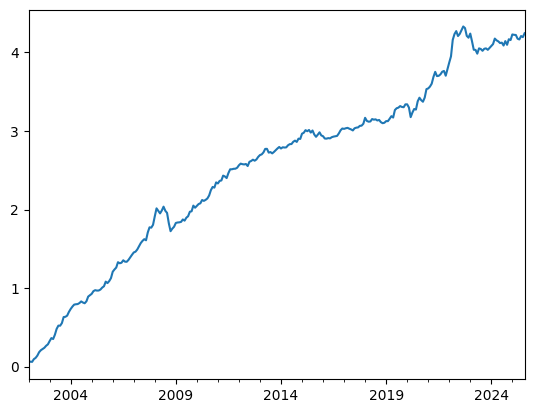

In [403]:
m = ret.mean() * 12
s = ret.std() * 12 ** 0.5
sr = m/s
sk = ret.skew()
print(f'''
Samples {ret.count()} months

Annulized
Mean = {m:.2%}
Std  = {s:.2%}
Skew = {sk:.2f}
SR   = {sr:.2f}
''')
ret.cumsum().plot()

# FF5 Benchmark
Conceptually, not a good benchmark:
- Macro invests in all asset classes (incl. fx, rates, commods, etc.) across regions, while FF5 only covers US equity factors
- FF5 might explain partially, as US equities is in fund's investment universe
---
Reasonable benchmark (alpha on FF5 adds uncorrelated return to their portfolio):
- US pension that primarily invest in US equity
- US big corp that are sensitive to US market cycles (high beta)
---
Inappropriate benchmark:
- Relative performance to macro peers
- Investors with access to global markets (not only US)

In [404]:
import pandas_datareader as pdr
# Fama-French 5 factors (2x3). Returns a list; [0] is the factor returns.
ff5 = pdr.get_data_famafrench('F-F_Research_Data_5_Factors_2x3', start='2000-01', end=None)[0]

/tmp/ipykernel_179/1621005415.py:3: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = pdr.get_data_famafrench('F-F_Research_Data_5_Factors_2x3', start='2000-01', end=None)[0]
/tmp/ipykernel_179/1621005415.py:3: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = pdr.get_data_famafrench('F-F_Research_Data_5_Factors_2x3', start='2000-01', end=None)[0]


In [405]:
ff5 = ff5 / 100
ff5.index = ff5.index.to_timestamp() + pd.offsets.MonthEnd(0)

In [406]:
reg_df = ff5.copy()
reg_df['Macro-RF'] = ret - reg_df['RF']
reg_df.dropna(inplace=True)

In [407]:
y = reg_df['Macro-RF']
x = reg_df.drop(columns=['RF','Macro-RF'])

As expected, not a good benchmark:
- FF5 factors did not explained much of the return, resulting in significantly high alpha
- Only US market factor is significant, beta ~0.24, except that HML has a relative small p-value (still insignificant), fund might have some value play
- R^2 is only 10% (90% left unexplained), FF5 failed to track the index properly

In [408]:
model = sm.OLS(y,sm.add_constant(x)).fit()
alpha = model.params['const'] * 12
print(f'Ann. alpha = {alpha:.2%}')
model.summary()

Ann. alpha = 13.90%


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Macro-RF   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     6.357
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           1.31e-05
Time:                        08:02:54   Log-Likelihood:                 536.60
No. Observations:                 284   AIC:                            -1061.
Df Residuals:                     278   BIC:                            -1039.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0116      0.002      5.060      0.000       0.007       0.016
Mkt-RF         0.2396      0.055      4.382      0.000       0.132       0.347
SMB           -0.0036      0.095     -0.038      0.970      -0.191       0.184
HML            0.1321      0.092      1.429      0.154      -0.050       0.314
RMW            0.0155      0.113      0.137      0.891      -0.207       0.238
CMA            0.1562      0.138      1.134      0.258      -0.115       0.427
==============================================================================
Omnibus:                       29.919   Durbin-Watson:                   1.620
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              126.512
Skew:                           0.247   Prob(JB):                     3.37e-28
Kurtosis:                       6.232   Cond. No.                         69.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Custom benchmark
Candidate factors:
- Momentum / Trend
- Carry
- Value
- Equity
- Rates
- Credit
- Volatility?
- Cycle
- DM vs EM Equity
- Risk On / Off

In [409]:
import yfinance as yf
import seaborn as sns

In [677]:
new = yf.download(['GLD'],period='max',interval='1d')['Close']
new_ret = new.resample('me').last().pct_change()
new_ret.dropna(inplace=True)

/tmp/ipykernel_179/299631747.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  new = yf.download(['GLD'],period='max',interval='1d')['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_179/299631747.py:2: FutureWarning: 'me' is deprecated and will be removed in a future version, please use 'ME' instead.
  new_ret = new.resample('me').last().pct_change()


In [678]:
new_ret.head()

Ticker,GLD
Date,
2004-12-31,-0.029255
2005-01-31,-0.036073
2005-02-28,0.031028
2005-03-31,-0.016311
2005-04-30,0.012377


In [679]:
jkp_ret = pd.read_csv('jkp_factors.csv')
jkp_ret[['location','name','ret']].groupby(['name','location']).count().unstack()

ret                                    
location            developed emerging frontier world world_ex_us
name                                                             
accruals                  468      380      104   948         468
debt_issuance             468      380      207   878         468
investment                468      407      208  1128         468
low_leverage              468      439      214  1187         468
low_risk                  468      443      214  1187         468
momentum                  465      441      214  1185         465
profit_growth             468      435      208  1176         468
profitability             468      392      214  1185         468
quality                   468      434      214  1176         468
seasonality               468      438      213  1187         468
short_term_reversal       467      445      214  1187         467
size                      468      446      214  1188         468
value                     468      435      210  1177         468

In [792]:
jkp_ret = pd.read_csv('jkp_factors.csv')
jkp_ret['long_name'] = jkp_ret['location'] + '_' + jkp_ret['name']
#jkp_ret = jkp_ret[jkp_ret['location']=='frontier']
jkp_ret = jkp_ret[['date','long_name','ret']]
jkp_ret = jkp_ret.set_index(['date','long_name']).unstack()
jkp_ret = jkp_ret.droplevel(axis=1,level=0)
jkp_ret.index = pd.to_datetime(jkp_ret.index)
jkp_ret = jkp_ret[['emerging_momentum','world_value']]
#jkp_ret = jkp_ret[['frontier_investment','developed_value','emerging_momentum']]

In [1027]:
factors = pd.read_excel('candidate_factors.xlsm',sheet_name='data')
meta = pd.read_excel('candidate_factors.xlsm',sheet_name='metadata')
factors.index = factors.iloc[:,0]
factors.index.name = 'Date'
factors = factors.iloc[:,[n for n in range(factors.shape[1]) if n%2==1]]

In [1028]:
meta

,Description,Ticker,NAME,SECURITY_DES,CRNCY
0,SG Trend,NEIXCTAT Index,NEIXCTAT,NEIXCTAT,USD
1,BBG FX Carry - Eq Risk G10/EM8,BSLFXC Index,BBG FX Carry ER,BSLFXC,USD
2,BBG G10 Carry,FXCTG10 Index,Bloomberg Cumulative FX Carry,Bloomberg Cumulative FX Carry,NaN
3,BBG EM8 Carry,FXCTEM8 Index,Bloomberg Cumulative FX Carry,Bloomberg Cumulative FX Carry,NaN
4,BBG Trend - Eq Risk Bond/Equity/Commodity/FX,BSLXAT Index,BBG Cross Asset Trend ER,BSLXAT,USD
5,BBG Equity Trend,BSLEQT Index,BBG Equity Trend ER,BSLEQT,USD
6,BBG Bond Trend,BSLBFT Index,BBG Bond Trend ER,BSLBFT,USD
7,BBG Commodity Trend,BSLCMT Index,BBG Commodity Trend ER,BSLCMT,USD
8,BBG FX Trend,BSLFXT Index,BBG FX Trend ER,BSLFXT,USD
9,BBG GlobalAgg investment grade debt,LEGATRUH Index,Global Aggregate,LEGATRUH,USD


In [1062]:
fret = factors[['BSLEQT Index','BSLBFT Index','BCOMRS Index','M1WO000V Index']].dropna()
#fret = factors[['M1WO Index','M1WOQU Index','M1WOMOM Index']].dropna().pct_change()

In [1068]:
#fret = jkp_ret.copy()
#fret = tsm_ret.copy()
#fret['Mkt-RF'] = ff5['Mkt-RF']
fret['Yield'] = factors['USYC5Y30 Index'].diff()
fret['RF'] = ff5['RF']
fret = pd.concat([fret],axis=1)
fret.dropna(inplace=True)

<Axes: >

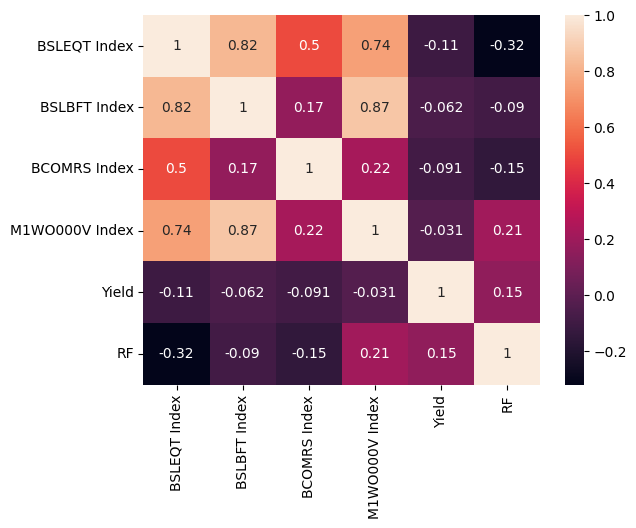

In [1069]:
sns.heatmap(fret.corr(),annot=True)

In [1070]:
reg_df = fret.copy()
reg_df['Macro-RF'] = ret - reg_df['RF']
reg_df.dropna(inplace=True)

In [1071]:
y = reg_df['Macro-RF']
x = reg_df.drop(columns=['RF','Macro-RF'])

In [1073]:
model = sm.OLS(y,sm.add_constant(x)).fit()
alpha = model.params['const'] * 12
print(f'Ann. alpha = {alpha:.2%}')
model.summary()

Ann. alpha = 92.44%


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Macro-RF   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.047
Date:                Tue, 03 Mar 2026   Prob (F-statistic):              0.391
Time:                        09:25:50   Log-Likelihood:                 359.97
No. Observations:                 203   AIC:                            -707.9
Df Residuals:                     197   BIC:                            -688.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0770      0.034      2.280      0.024       0.010       0.144
BSLEQT Index      -0.0004      0.000     -1.215      0.226      -0.001       0.000
BSLBFT Index      -0.0002      0.000     -0.601      0.548      -0.001       0.000
BCOMRS Index    1.266e-05   5.43e-05      0.233      0.816   -9.44e-05       0.000
M1WO000V Index  2.076e-06    2.1e-06      0.986      0.325   -2.07e-06    6.23e-06
Yield             -0.0002      0.000     -1.115      0.266      -0.001       0.000
==============================================================================
Omnibus:                       20.087   Durbin-Watson:                   1.750
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               78.740
Skew:                           0.105   Prob(JB):                     7.98e-18
Kurtosis:                       6.044   Cond. No.                     8.98e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.98e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

<Axes: xlabel='Date'>

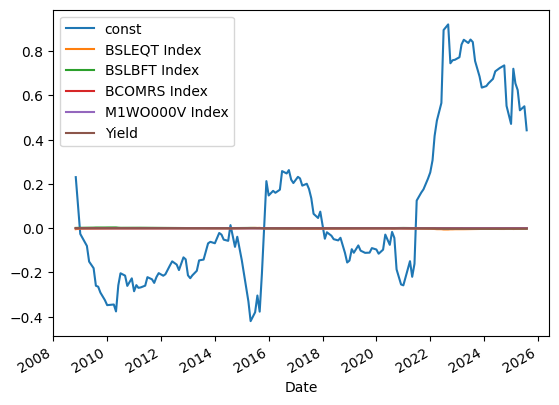

In [1074]:
from statsmodels.regression.rolling import RollingOLS
rols = RollingOLS(y,sm.add_constant(x),window=12*5).fit()
rols.params.plot()

In [1075]:
res = y - model.predict(sm.add_constant(x))

<Axes: >

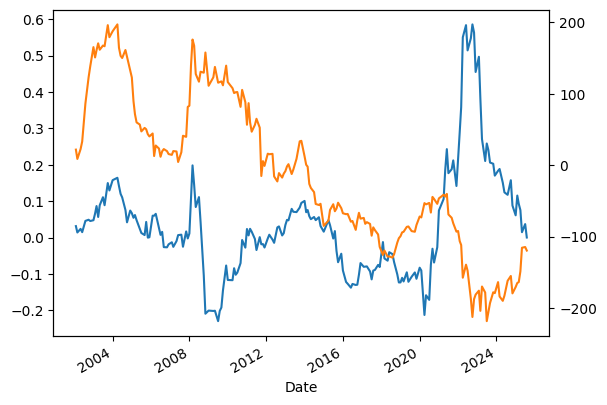

In [1077]:
res.cumsum().plot()
x['Yield'].cumsum().plot(secondary_y=True)